In [61]:
# !pip install mne

In [62]:
import os
import mne
import urllib.request
import numpy as np
import pandas as pd
import re
import requests
from tqdm import tqdm
import matplotlib.pyplot as plt

mne.set_log_level('Warning')

In [63]:
# Configuration and Parameter Dictionary
CONFIG = {
    'tmin': -5.0,
    'tmax': 15.0,
    'baseline': (None, 0.0),
    'reject_ptp': dict(eeg=250e-6),
    'flat_ptp': dict(eeg=1e-6)
}

In [64]:
BASE_URL = "https://physionet.org/files/chbmit/1.0.0/{subj}/{subj}-summary.txt"
SUBJECT_IDS = [f"chb{n:02d}" for n in range(1, 25)]

In [65]:
def fetch_summary(subject_id: str) -> str | None:
    resp = requests.get(BASE_URL.format(subj=subject_id), timeout=20)
    return resp.text if resp.status_code == 200 else None

In [66]:
def parse_summary(text: str) -> list[dict]:
    entries = []
    blocks = re.split(r"(?=File Name:)", text)
    for block in blocks:
        fname_match = re.search(r"File Name:\s*(\S+)", block)
        nseiz_match = re.search(r"Number of Seizures in File:\s*(\d+)", block)
        if not fname_match or not nseiz_match or int(nseiz_match.group(1)) == 0:
            continue

        for onset in re.findall(r"Seizure(?:\s+\d+)?\s+Start Time:\s*(\d+)\s*seconds", block):
            entries.append({"file_name": fname_match.group(1), "seizure_onset": int(onset)})
    return entries

In [67]:
cohort_dict = {subj: parse_summary(text) for subj in SUBJECT_IDS if (text := fetch_summary(subj))}
cohort_df = pd.DataFrame([{"subject_id": s, **e} for s, entries in cohort_dict.items() for e in entries])
print(f"Total seizure events logged: {len(cohort_df)}")

Total seizure events logged: 198


In [68]:
all_raws = []
EDF_BASE_URL = "https://physionet.org/files/chbmit/1.0.0/"
sample_df = cohort_df.head(3)

In [69]:
cohort_df.head(3)

,subject_id,file_name,seizure_onset
0,chb01,chb01_03.edf,2996
1,chb01,chb01_04.edf,1467
2,chb01,chb01_15.edf,1732


In [70]:
for _, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Fetching EDFs"):
  fname = row['file_name']
  url = f"{EDF_BASE_URL}{row['subject_id']}/{fname}"

  if not os.path.exists(fname):
      urllib.request.urlretrieve(url, fname)

  raw = mne.io.read_raw_edf(fname, preload=True, verbose=False)

  # Inject annotations: 40s Background (at 10s) and Seizure onset
  annotations = mne.Annotations(
      onset=[10.0, row['seizure_onset']],
      duration=[40.0, 40.0],
      description=['Non-Seizure', 'Seizure']
  )
  raw.set_annotations(annotations)

  new_names = {ch: ch.replace('EEG ', '').replace('-REF', '').strip() for ch in raw.ch_names}
  raw.rename_channels(new_names)
  all_raws.append(raw)

Fetching EDFs:   0%|          | 0/3 [00:00<?, ?it/s]/tmp/ipykernel_3388/3993855032.py:8: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(fname, preload=True, verbose=False)
Fetching EDFs:  33%|███▎      | 1/3 [00:00<00:00,  2.18it/s]/tmp/ipykernel_3388/3993855032.py:8: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(fname, preload=True, verbose=False)
Fetching EDFs:  67%|██████▋   | 2/3 [00:01<00:00,  1.91it/s]/tmp/ipykernel_3388/3993855032.py:8: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(fname, preload=True, verbose=False)
Fetching EDFs: 100%|██████████| 3/3 [00:01<00:00,  1.98it/s]


In [85]:
# @title Unfiltered Epoching & Threshold visualisation
# clinical reality
CONFIG['reject_ptp'] = dict(eeg=2500e-6)

raw_cohort = mne.concatenate_raws(all_raws, verbose=False)

# Bandpass filter (necessary for removing baseline drift and high freq EMG)
raw_cohort.filter(l_freq=1.0, h_freq=50.0, verbose=False)

events, event_dict = mne.events_from_annotations(raw_cohort, verbose=False)
target_events = {'Seizure': event_dict['Seizure'], 'Non-Seizure': event_dict['Non-Seizure']}
picks = mne.pick_types(raw_cohort.info, eeg=True)

In [86]:
# Generate epochs with no rejection first, to calculate amplitude distributions
cohort_epochs = mne.Epochs(
    raw=raw_cohort, events=events, event_id=target_events,
    tmin=CONFIG['tmin'], tmax=CONFIG['tmax'], baseline=CONFIG['baseline'],
    picks=picks, preload=True, reject=None, verbose=False
)

In [87]:
# Calculate Peak-to-Peak (PTP) amplitude for every epoch
data = cohort_epochs.get_data()
ptp_amplitudes = np.ptp(data, axis=2).max(axis=1) * 1e6

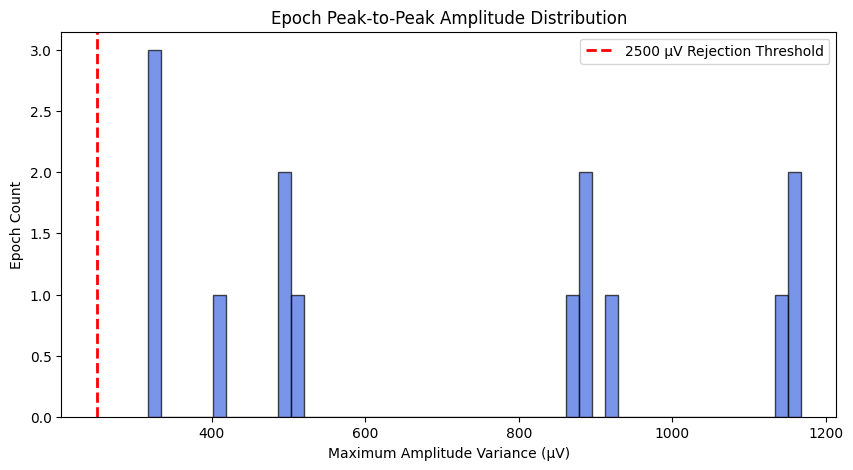

In [97]:
# plot
plt.figure(figsize=(10, 5))
plt.hist(ptp_amplitudes, bins=50, color='royalblue', edgecolor='black', alpha=0.7)
plt.axvline(x=250, color='red', linestyle='dashed', linewidth=2, label='2500 µV Rejection Threshold')
plt.title("Epoch Peak-to-Peak Amplitude Distribution")
plt.xlabel("Maximum Amplitude Variance (µV)")
plt.ylabel("Epoch Count")
plt.legend()
plt.show()

In [89]:
#@title Artifact Rejection, condition splitting and time-lock
cohort_epochs.drop_bad(reject=CONFIG['reject_ptp'], flat=CONFIG['flat_ptp'])

epochs_seizure = cohort_epochs['Seizure']
epochs_non_seizure = cohort_epochs['Non-Seizure']

print("\n" + "=" * 50)
print(f"{'BATCH COHORT AUDIT':^50}")
print("=" * 50)
print(f"  Epochs Retained Post-Threshold : {len(cohort_epochs)}")
print(f"  Seizure Trials                 : {len(epochs_seizure)}")
print(f"  Non-Seizure Trials             : {len(epochs_non_seizure)}")
print("=" * 50)


                BATCH COHORT AUDIT                
  Epochs Retained Post-Threshold : 14
  Seizure Trials                 : 7
  Non-Seizure Trials             : 7


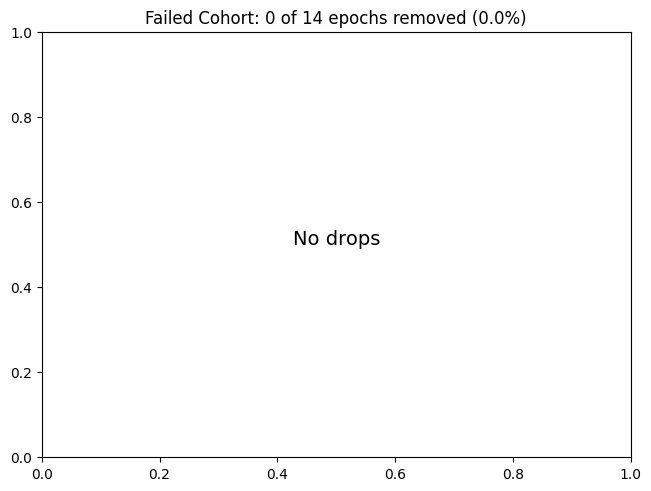

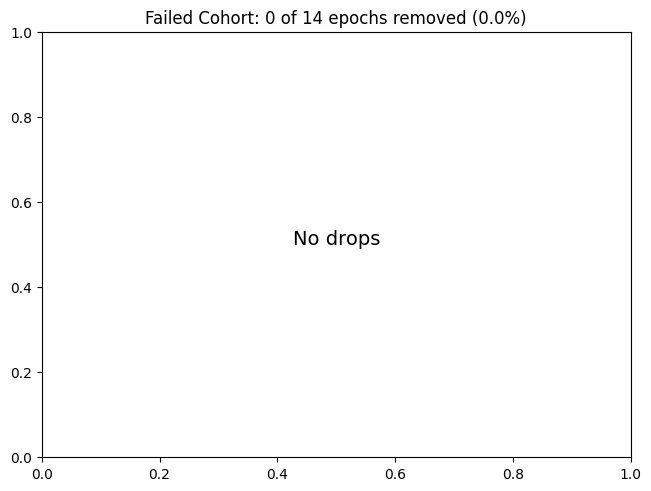

In [90]:
cohort_epochs.plot_drop_log(subject="Failed Cohort")

/tmp/ipykernel_3388/4229896273.py:4: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  epochs_seizure.average().plot(axes=axes[0], spatial_colors=True, show=False)
/tmp/ipykernel_3388/4229896273.py:7: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  epochs_non_seizure.average().plot(axes=axes[1], spatial_colors=True, show=False)


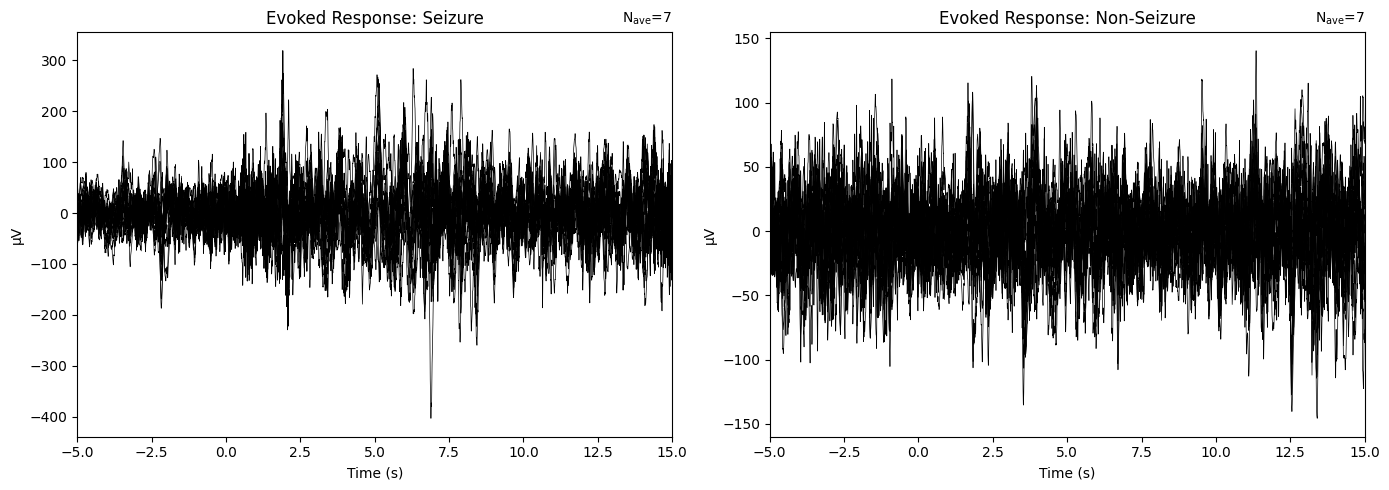

In [91]:
# Visualize Time-Locked Evoked Responses (now showing -5s to 15s)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if len(epochs_seizure) > 0:
    epochs_seizure.average().plot(axes=axes[0], spatial_colors=True, show=False)
    axes[0].set_title("Evoked Response: Seizure")
if len(epochs_non_seizure) > 0:
    epochs_non_seizure.average().plot(axes=axes[1], spatial_colors=True, show=False)
    axes[1].set_title("Evoked Response: Non-Seizure")
plt.tight_layout()
plt.show()

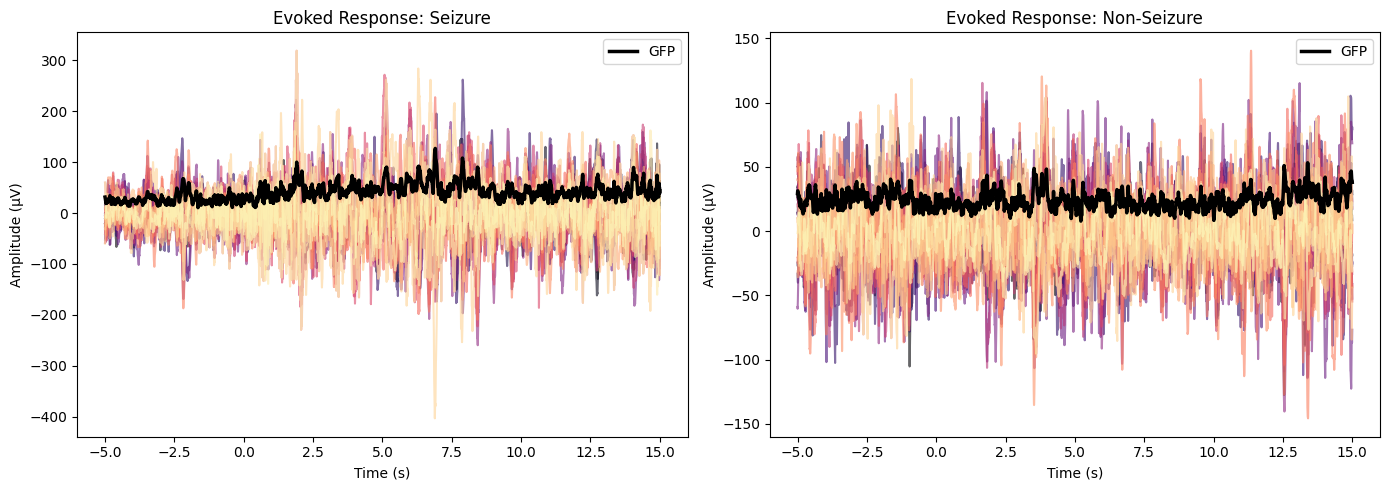

In [96]:
# Visualize Time-Locked Evoked Responses with Colormap and GFP
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
conditions = [(epochs_seizure, "Seizure"), (epochs_non_seizure, "Non-Seizure")]

for ax, (ep, title) in zip(axes, conditions):
    if len(ep) > 0:
        data = ep.average().get_data() * 1e6

        # Colorize and plot all channels simultaneously
        ax.set_prop_cycle('color', plt.cm.magma(np.linspace(0, 1, data.shape[0])))
        ax.plot(ep.times, data.T, alpha=0.6)

        # Overlay GFP (Spatial Variance)
        ax.plot(ep.times, np.std(data, axis=0), color='black', linewidth=2.5, label='GFP')

        ax.set(title=f"Evoked Response: {title}", xlabel="Time (s)", ylabel="Amplitude (µV)")
        ax.legend(loc='upper right')

plt.tight_layout()
plt.show()